In [2]:
!pip install "https://github.com/Dao-AILab/flash-attention/releases/download/v2.8.3/flash_attn-2.8.3%2Bcu12torch2.9cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.8/253.8 MB 8.4 MB/s eta 0:00:0000:0100:01


In [3]:
!rm -rf "/content/SimpleVLLM"

In [4]:
!git clone https://github.com/Ajax0564/SimpleVLLM.git

Cloning into 'SimpleVLLM'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 140 (delta 60), reused 116 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 253.43 KiB | 1.17 MiB/s, done.
Resolving deltas: 100% (60/60), done.


In [5]:
import os
import sys

# Point directly to the 'src' directory
src_path = os.path.abspath("/content/SimpleVLLM/src")
if src_path not in sys.path:
    sys.path.append(src_path)

print("Successfully added to sys.path:", src_path)

Successfully added to sys.path: /content/SimpleVLLM/src


In [6]:
import sys

# Purge all simplevllm modules from Python's cache
for module in list(sys.modules.keys()):
    if module.startswith("simplevllm"):
        del sys.modules[module]

# Re-import core engine and model functions
from simplevllm.engine import ContinuousBatchEngine, PagedKVManager, SequenceState
from simplevllm.models import Qwen3Config, get_qwen3_model, get_qwen3_tokenizer

print("✓ Successfully imported Qwen3Config and SimpleVLLM modules!")
print("Config max_batch_size:", Qwen3Config["max_batch_size"])

✓ Successfully imported Qwen3Config and SimpleVLLM modules!
Config max_batch_size: 8


Loading Hugging Face Qwen3-0.6B model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

--- WARMUP PHASE ---


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Warmup complete.

Starting Unified Benchmark (Gen Length: 1024)...

--- Testing Batch Size: 1 ---
[Custom Engine] TPS:  50.86 tokens/s | Peak VRAM: 6.03 GB
[HF model.gen]  TPS:  21.81 tokens/s | Peak VRAM: 6.14 GB

--- Testing Batch Size: 2 ---
[Custom Engine] TPS: 100.00 tokens/s | Peak VRAM: 6.04 GB
[HF model.gen]  TPS:  45.76 tokens/s | Peak VRAM: 6.26 GB

--- Testing Batch Size: 4 ---
[Custom Engine] TPS: 192.59 tokens/s | Peak VRAM: 6.04 GB
[HF model.gen]  TPS:  91.30 tokens/s | Peak VRAM: 6.49 GB

--- Testing Batch Size: 8 ---
[Custom Engine] TPS: 372.50 tokens/s | Peak VRAM: 6.06 GB
[HF model.gen]  TPS: 182.73 tokens/s | Peak VRAM: 6.94 GB


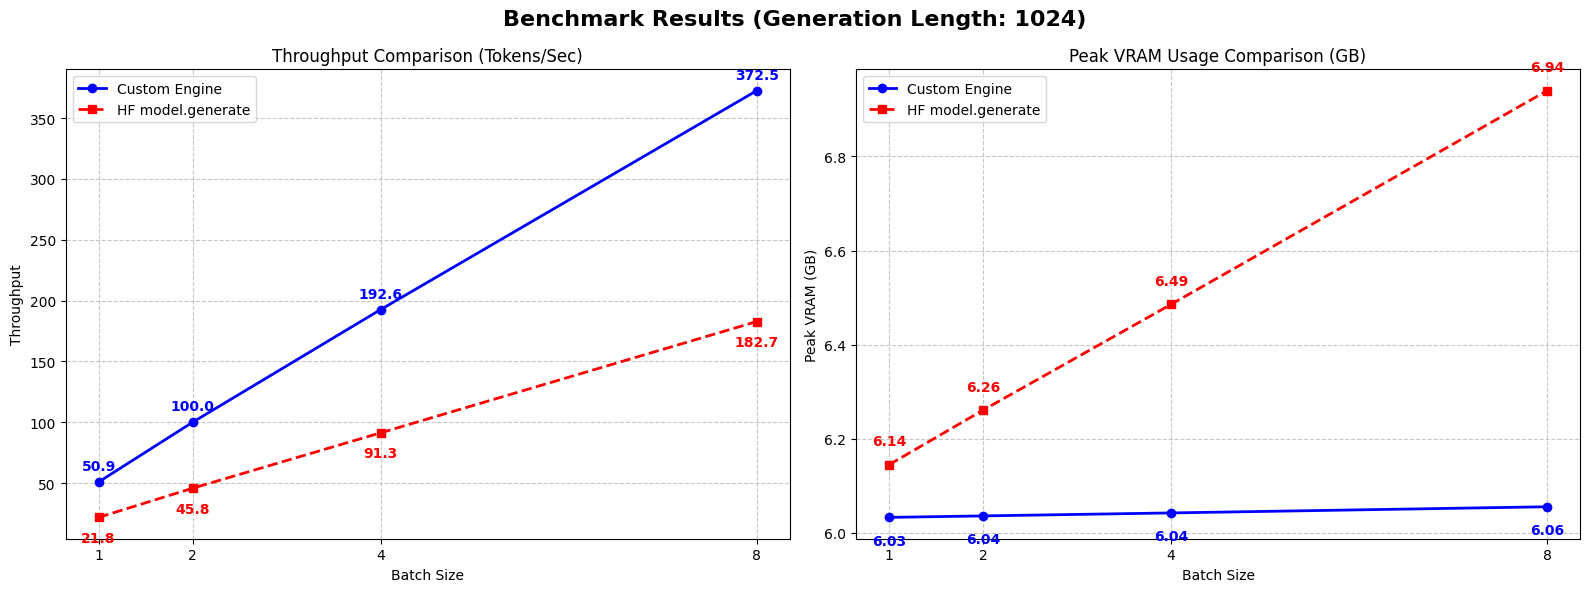

In [7]:
import time
import gc
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
torch.manual_seed(123)
device = "cuda" if torch.cuda.is_available() else "cpu"

def run_unified_benchmark(batch_sizes=[1, 2, 4, 8], max_new_tokens=1024, prompt_text="Generate a very long and detailed story about artificial intelligence."):
    custom_tps_results, hf_tps_results = [], []
    custom_mem_results, hf_mem_results = [], []

    print("Loading Hugging Face Qwen3-0.6B model...")
    hf_model_id = "Qwen/Qwen3-0.6B"
    hf_tokenizer = AutoTokenizer.from_pretrained(hf_model_id)
    hf_model = AutoModelForCausalLM.from_pretrained(
        hf_model_id,
        dtype=torch.bfloat16,
        device_map="cuda",
        attn_implementation="flash_attention_2"
    )
    if hf_tokenizer.pad_token is None:
        hf_tokenizer.pad_token = hf_tokenizer.eos_token

    # Prepare prompts
    custom_prompt_ids = hf_tokenizer.encode(prompt_text)
    hf_input_ids = hf_tokenizer(prompt_text, return_tensors="pt").input_ids.to("cuda")
    
    # Initialize a new KV Manager with enough blocks for BS=8 (128 blocks)
    local_mgr = PagedKVManager(Qwen3Config, max_blocks=128, device="cuda")
    model = get_qwen3_model()
    model.to('cuda')
    bench_engine = ContinuousBatchEngine(model, local_mgr, Qwen3Config)

    print("--- WARMUP PHASE ---")
    # Custom Engine warmup
    bench_engine.reset()
    bench_engine.add_sequence(custom_prompt_ids, max_gen_len=150)
    while bench_engine.waiting_room or bench_engine.active:
        bench_engine.step()

    # HF Engine warmup
    with torch.inference_mode():
        _ = hf_model.generate(hf_input_ids, max_new_tokens=150, do_sample=False)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    print("Warmup complete.\n")

    print(f"Starting Unified Benchmark (Gen Length: {max_new_tokens})...")
    for bs in batch_sizes:
        print(f"\n--- Testing Batch Size: {bs} ---")

        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        bench_engine.reset()

        for _ in range(bs):
            bench_engine.add_sequence(custom_prompt_ids, max_gen_len=max_new_tokens)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.time()
        total_custom_tokens = 0

        while bench_engine.waiting_room or bench_engine.active:
            finished = bench_engine.step()
            for sid, tokens in finished.items():
                total_custom_tokens += len(tokens) - len(custom_prompt_ids)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.time()
        custom_peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 3)
        custom_duration = end_time - start_time
        custom_tps = total_custom_tokens / custom_duration

        custom_tps_results.append(custom_tps)
        custom_mem_results.append(custom_peak_mem)
        print(f"[Custom Engine] TPS: {custom_tps:6.2f} tokens/s | Peak VRAM: {custom_peak_mem:.2f} GB")

        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        batch_input_ids = hf_input_ids.repeat(bs, 1)
        attention_mask = torch.ones_like(batch_input_ids)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.time()

        with torch.inference_mode():
            _ = hf_model.generate(
                batch_input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                min_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True
            )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.time()
        hf_peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 3)
        hf_duration = end_time - start_time
        total_hf_tokens = bs * max_new_tokens
        hf_tps = total_hf_tokens / hf_duration

        hf_tps_results.append(hf_tps)
        hf_mem_results.append(hf_peak_mem)
        print(f"[HF model.gen]  TPS: {hf_tps:6.2f} tokens/s | Peak VRAM: {hf_peak_mem:.2f} GB")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Subplot 1: Throughput ---
    ax1.plot(batch_sizes, custom_tps_results, marker='o', linestyle='-', color='b', linewidth=2, label='Custom Engine')
    ax1.plot(batch_sizes, hf_tps_results, marker='s', linestyle='--', color='r', linewidth=2, label='HF model.generate')
    ax1.set_title(f'Throughput Comparison (Tokens/Sec)')
    ax1.set_xlabel('Batch Size')
    ax1.set_ylabel('Throughput')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_xticks(batch_sizes)
    ax1.legend()

    max_tps = max(max(custom_tps_results), max(hf_tps_results))
    for x, y_c, y_h in zip(batch_sizes, custom_tps_results, hf_tps_results):
        if y_c >= y_h:
            ax1.text(x, y_c + (max_tps * 0.02), f"{y_c:.1f}", ha='center', va='bottom', color='b', fontweight='bold')
            ax1.text(x, y_h - (max_tps * 0.03), f"{y_h:.1f}", ha='center', va='top', color='r', fontweight='bold')
        else:
            ax1.text(x, y_c - (max_tps * 0.03), f"{y_c:.1f}", ha='center', va='top', color='b', fontweight='bold')
            ax1.text(x, y_h + (max_tps * 0.02), f"{y_h:.1f}", ha='center', va='bottom', color='r', fontweight='bold')

    ax2.plot(batch_sizes, custom_mem_results, marker='o', linestyle='-', color='b', linewidth=2, label='Custom Engine')
    ax2.plot(batch_sizes, hf_mem_results, marker='s', linestyle='--', color='r', linewidth=2, label='HF model.generate')
    ax2.set_title(f'Peak VRAM Usage Comparison (GB)')
    ax2.set_xlabel('Batch Size')
    ax2.set_ylabel('Peak VRAM (GB)')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.set_xticks(batch_sizes)
    ax2.legend()

    max_mem = max(max(custom_mem_results), max(hf_mem_results))
    for x, y_c, y_h in zip(batch_sizes, custom_mem_results, hf_mem_results):
        if y_c >= y_h:
            ax2.text(x, y_c + (max_mem * 0.005), f"{y_c:.2f}", ha='center', va='bottom', color='b', fontweight='bold')
            ax2.text(x, y_h - (max_mem * 0.005), f"{y_h:.2f}", ha='center', va='top', color='r', fontweight='bold')
        else:
            ax2.text(x, y_c - (max_mem * 0.005), f"{y_c:.2f}", ha='center', va='top', color='b', fontweight='bold')
            ax2.text(x, y_h + (max_mem * 0.005), f"{y_h:.2f}", ha='center', va='bottom', color='r', fontweight='bold')

    plt.suptitle(f"Benchmark Results (Generation Length: {max_new_tokens})", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Clean up HF model to free memory if needed afterwards
    del hf_model,model
    gc.collect()
    torch.cuda.empty_cache()

# Run the unified benchmark (using a length of 1024 for reasonable speed, change if needed)
run_unified_benchmark(batch_sizes=[1, 2, 4, 8], max_new_tokens=1024)


In [8]:
# Load model and tokenizer
tokenizer = get_qwen3_tokenizer()
model = get_qwen3_model()

print("✓ Model and Tokenizer initialized on device successfully!")

✓ Model and Tokenizer initialized on device successfully!


In [9]:
import torch
torch.manual_seed(123)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

In [10]:
from simplevllm.models import Qwen3Config
mgr = PagedKVManager(Qwen3Config, max_blocks=32, device=device)

In [11]:
prompt = "Give me a short introduction to large language models."

input_token_ids1 = tokenizer.encode(prompt)

In [12]:
prompt = "Give me a short introduction to AI"

input_token_ids3 = tokenizer.encode(prompt)

In [13]:
prompt = "Give me a short introduction to Embeddings in nlp"

input_token_ids2 = tokenizer.encode(prompt)

In [16]:
import itertools
from collections import deque
import torch

class ContinuousBatchEngine:
    """ContinuousBatchEngine with reusable GPU staging buffers (Standalone)."""

    def __init__(self, model, kv_mgr, cfg):
        # --- Core Engine State ---
        self.model = model
        self.model.eval()
        self.kv_mgr = kv_mgr
        self.cfg = cfg
        self.active = {}
        self.id_gen = itertools.count()
        self.device = next(model.parameters()).device

        self.max_batch = cfg.get("max_batch_size", 4)
        self.chunk_size = cfg.get("chunk_size", 256)
        self.waiting_room = deque()

        # --- Pre-allocated GPU Staging Buffers ---
        self.max_tokens_per_step = self.max_batch * self.chunk_size
        self.max_blocks_per_seq = (
            self.cfg["context_length"] + self.cfg["block_size"] - 1
        ) // self.cfg["block_size"]

        self.gpu_input_ids = torch.empty(
            self.max_tokens_per_step,
            dtype=torch.long,
            device=self.device,
        )
        self.gpu_slot_mapping = torch.empty(
            self.max_tokens_per_step,
            dtype=torch.long,
            device=self.device,
        )
        self.gpu_positions = torch.empty(
            self.max_tokens_per_step,
            dtype=torch.long,
            device=self.device,
        )
        self.gpu_position_template = torch.arange(
            self.max_tokens_per_step,
            dtype=torch.long,
            device=self.device,
        )
        self.gpu_block_table = torch.empty(
            self.max_batch,
            self.max_blocks_per_seq,
            dtype=torch.int32,
            device=self.device,
        )
        self.gpu_block_table.zero_()
        self.gpu_sequence_block_table = torch.empty_like(self.gpu_block_table)
        self.gpu_sequence_block_table.zero_()
        self.gpu_sequence_rows = {}
        self.gpu_sequence_block_counts = {}
        self.free_gpu_rows = deque(range(self.max_batch))

        self.gpu_cu_q = torch.empty(
            self.max_batch + 1,
            dtype=torch.int32,
            device=self.device,
        )
        self.gpu_cu_k = torch.empty(
            self.max_batch + 1,
            dtype=torch.int32,
            device=self.device,
        )
        self.gpu_seqlens = torch.empty(
            self.max_batch,
            dtype=torch.int32,
            device=self.device,
        )
        self.gpu_selected_indices = torch.empty(
            self.max_batch,
            dtype=torch.long,
            device=self.device,
        )
        self.gpu_selected_tokens = torch.empty(
            self.max_batch,
            dtype=torch.long,
            device=self.device,
        )
        self.gpu_cos = torch.empty(
            self.max_tokens_per_step,
            self.model.cos_buf.shape[-1],
            dtype=self.model.cos_buf.dtype,
            device=self.device,
        )
        self.gpu_sin = torch.empty_like(self.gpu_cos)

    def add_sequence(self, prompt_ids, max_gen_len=128):
        if not prompt_ids:
            raise ValueError("prompt_ids cannot be empty")

        max_length = self.cfg["context_length"]
        if len(prompt_ids) + max_gen_len > max_length:
            raise ValueError(
                f"Prompt plus generation length exceeds context length {max_length}"
            )

        sid = next(self.id_gen)
        self.waiting_room.append({
            "sid": sid,
            "prompt_ids": list(prompt_ids),
            "max_gen_len": max_gen_len,
        })

    def reset(self):
        for state in list(self.active.values()):
            self.kv_mgr.free(state)

        self.active.clear()
        self.waiting_room.clear()
        self.id_gen = itertools.count()

        self.gpu_sequence_rows.clear()
        self.gpu_sequence_block_counts.clear()
        self.free_gpu_rows = deque(range(self.max_batch))
        self.gpu_block_table.zero_()
        self.gpu_sequence_block_table.zero_()

    def stats(self):
        return {
            "active_sequences": len(self.active),
            "waiting_sequences": len(self.waiting_room),
            "kv_cache": self.kv_mgr.stats(),
        }

    def _try_schedule_waiting(self):
        while self.waiting_room and len(self.active) < self.max_batch:
            req = self.waiting_room[0]
            matched_blocks = self.kv_mgr.get_prefix_blocks(req['prompt_ids'])

            self.waiting_room.popleft()
            self.active[req['sid']] = SequenceState(
                req['sid'], req['prompt_ids'], req['max_gen_len'],
                self.cfg, self.device, matched_blocks=matched_blocks
            )

    def _get_gpu_sequence_row(self, state):
        if state.id not in self.gpu_sequence_rows:
            if not self.free_gpu_rows:
                raise RuntimeError("No reusable GPU sequence rows available")
            row = self.free_gpu_rows.popleft()
            self.gpu_sequence_rows[state.id] = row
            self.gpu_sequence_block_counts[state.id] = 0
            self.gpu_sequence_block_table[row].zero_()
        return self.gpu_sequence_rows[state.id]

    def _release_gpu_sequence_row(self, state_id):
        row = self.gpu_sequence_rows.pop(state_id, None)
        self.gpu_sequence_block_counts.pop(state_id, None)
        if row is not None:
            self.gpu_sequence_block_table[row].zero_()
            self.free_gpu_rows.append(row)

    def step(self):
        self._try_schedule_waiting()
        if not self.active:
            return {}

        states = list(self.active.values())
        chunks = [
            min(self.chunk_size, s.prompt_len - s.processed_len)
            if s.is_prefill else 1
            for s in states
        ]
        starts = [s.processed_len for s in states]
        is_decoding = all(not s.is_prefill for s in states)
        non_blocking = self.device.type == "cuda"
        batch_size = len(states)

        for state, chunk_len in zip(states, chunks):
            self.kv_mgr.allocate(state, chunk_len)
            state.update_metadata(chunk_len)

        self.gpu_cu_q[0] = 0
        self.gpu_cu_k[0] = 0
        q_acc, k_acc = 0, 0
        token_offset = 0
        max_num_blocks_per_seq = 0
        max_seqlen_k = 0
        block_size = self.cfg["block_size"]

        for row, (state, start, chunk_len) in enumerate(
            zip(states, starts, chunks)
        ):
            end = start + chunk_len
            next_offset = token_offset + chunk_len

            self.gpu_input_ids[token_offset:next_offset].copy_(
                state.tokens[start:end],
                non_blocking=non_blocking,
            )
            self.gpu_slot_mapping[token_offset:next_offset].copy_(
                state.slot_mapping[start:end],
                non_blocking=non_blocking,
            )
            self.gpu_positions[token_offset:next_offset].copy_(
                self.gpu_position_template[:chunk_len]
            )
            self.gpu_positions[token_offset:next_offset].add_(start)
            self.gpu_cos[token_offset:next_offset].copy_(
                self.model.cos_buf[start:end],
                non_blocking=non_blocking,
            )
            self.gpu_sin[token_offset:next_offset].copy_(
                self.model.sin_buf[start:end],
                non_blocking=non_blocking,
            )

            q_acc += chunk_len
            k_acc += end
            max_seqlen_k = max(max_seqlen_k, end)
            self.gpu_cu_q[row + 1] = q_acc
            self.gpu_cu_k[row + 1] = k_acc
            self.gpu_seqlens[row] = end

            max_num_blocks_per_seq = max(
                max_num_blocks_per_seq,
                (end + block_size - 1) // block_size,
            )

            sequence_row = self._get_gpu_sequence_row(state)
            previous_count = self.gpu_sequence_block_counts[state.id]
            current_count = state.block_count
            if current_count > previous_count:
                self.gpu_sequence_block_table[
                    sequence_row,
                    previous_count:current_count,
                ].copy_(
                    state.block_table[previous_count:current_count],
                    non_blocking=non_blocking,
                )
                self.gpu_sequence_block_counts[state.id] = current_count

            token_offset = next_offset

        active_block_table = self.gpu_block_table[
            :batch_size,
            :max_num_blocks_per_seq,
        ]
        active_block_table.zero_()
        for row, state in enumerate(states):
            sequence_row = self.gpu_sequence_rows[state.id]
            active_block_table[row].copy_(
                self.gpu_sequence_block_table[
                    sequence_row,
                    :max_num_blocks_per_seq,
                ]
            )

        meta = {
            "is_decoding": is_decoding,
            "slot_mapping": self.gpu_slot_mapping[:token_offset],
            "cu_seqlens_q": self.gpu_cu_q[:batch_size + 1],
            "cu_seqlens_k": self.gpu_cu_k[:batch_size + 1],
            "max_seqlen_q": max(chunks),
            "max_seqlen_k": max_seqlen_k,
            "seqlens": self.gpu_seqlens[:batch_size],
            "block_table": active_block_table,
            "block_size": block_size,
            "cos": self.gpu_cos[:token_offset].unsqueeze(1),
            "sin": self.gpu_sin[:token_offset].unsqueeze(1),
        }

        with torch.inference_mode():
            logits = self.model(
                self.gpu_input_ids[:token_offset],
                self.kv_mgr.k_cache,
                self.kv_mgr.v_cache,
                meta,
            )

        finished = {}
        curr_offset = 0
        next_tokens = torch.argmax(logits, dim=-1)
        selected_count = 0
        selected_states = []

        for state, chunk_len in zip(states, chunks):
            last_idx = curr_offset + chunk_len - 1
            if state.processed_len >= state.prompt_len:
                self.gpu_selected_indices[selected_count] = last_idx
                selected_states.append(state)
                selected_count += 1
            curr_offset += chunk_len

        if selected_count:
            torch.gather(
                next_tokens,
                0,
                self.gpu_selected_indices[:selected_count],
                out=self.gpu_selected_tokens[:selected_count],
            )
            selected_tokens = self.gpu_selected_tokens[:selected_count].cpu().tolist()

            for state, token_id in zip(selected_states, selected_tokens):
                should_continue = state.append_token(token_id)
                if not should_continue:
                    finished[state.id] = state.tokens[:state.num_tokens].tolist()
                    self.kv_mgr.free(state)
                    self._release_gpu_sequence_row(state.id)
                    del self.active[state.id]

        return finished

    def step_single(self):
        """Run one engine step and yield newly generated token events."""
        previous_lengths = {
            sid: state.num_tokens for sid, state in self.active.items()
        }
        finished = self.step()

        for sid, state in self.active.items():
            start = previous_lengths.get(sid, state.num_tokens)
            for token_id in state.tokens[start:state.num_tokens].tolist():
                yield {
                    "sequence_id": sid,
                    "token_id": token_id,
                    "finished": False,
                }

        for sid, tokens in finished.items():
            start = previous_lengths.get(sid, len(tokens))
            for token_id in tokens[start:]:
                yield {
                    "sequence_id": sid,
                    "token_id": token_id,
                    "finished": True,
                    "tokens": tokens,
                }


In [17]:
batched_engine = ContinuousBatchEngine(model, mgr, Qwen3Config)
print("BatchedEngine ready")

BatchedEngine ready


In [18]:
my_prompts = [
    input_token_ids1,
    input_token_ids2,
    input_token_ids3
]
batched_engine.reset()
for prompt in my_prompts:
    batched_engine.add_sequence(prompt,max_gen_len = 512)


while batched_engine.waiting_room or batched_engine.active:
    finished = batched_engine.step()
     # Print results as they come in
    for sid, tokens in finished.items():
        print(f"Slot {sid} finished. Total length: {len(tokens)}")
        print(tokenizer.decode(tokens))
        print("-" * 30)

Slot 0 finished. Total length: 530
<|im_start|>user
Give me a short introduction to large language models.<|im_end|>
<|im_start|>assistant
<think>

:
 of電子郵件,/,and anddef,and country this research.and,,,es, or.".1,. this,,, ,. or,.and1..,s.           .,.
 may分析, there, is非法.com在, or...

,,.com.,c. and, or,  is,,...The......,... and,,,. a.world,._or,,..:........,h.al.......false,. =,,,,,,,,,,, And.,,,,,,,strол...

,s.nasa,,,, or,或..We,,..We5,,.A,:,,.,,, or、,,, , is,_newsOr,,,, ,.,,..,.,.And,.com,_or,,或uary,_rev,,, =,“.,,,,ernational And,,,, The and and,,,,,,.,,,,,,,..Or forensic,,,,_analysis,,,,...,.ernationalernational,,,,.,. or, or在_all_all,,,,,,,,,, Analysis “	,,,,,,,,,,,,,,.,,,..,,,มน或,会,, with,,.A,, ,,, ,,, , and and,.,,,,        ,,,,, andand.,,,,...,,,,,,,. or,,,, ,, ,,,,,,,,,,,  :,,,,,,,,,, two أ国家国家 �,, �中国6.or .,,,,,,., ,...,...,..,.,,,,,,,,,,, .,,,, � �,..,,,,,,..,.,.....,.,..,.,,,,,,,,,,,,,,,.,,有,,,,,,,,,,,,,,,..,.,.,或.,,,.
------------------------------
Slot 1 finished. Tota

In [14]:
! pip install gradio

In [15]:
import os
import threading
import uuid

import gradio as gr
import torch


class GradioRuntime:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = tokenizer
        self.model = model

        max_blocks = int(os.getenv("SIMPLEVLLM_MAX_BLOCKS", "256"))
        self.kv_manager = PagedKVManager(
            Qwen3Config,
            max_blocks=max_blocks,
            device=self.device,
        )
        self.engine = ContinuousBatchEngine(
            self.model,
            self.kv_manager,
            Qwen3Config,
        )
        self.conversations: dict[str, list[dict[str, str]]] = {}
        self.lock = threading.Lock()

    def _encode_history(self, history: list[dict[str, str]]) -> list[int]:
        prompt_ids: list[int] = []
        for item in history:
            turn = f"<|im_start|>{item['role']}\n{item['content']}<|im_end|>\n"
            prompt_ids.extend(self.tokenizer.encode(turn, chat_wrapped=False))

        prompt_ids.extend(
            self.tokenizer.encode("<|im_start|>assistant\n", chat_wrapped=False)
        )
        return prompt_ids

    def stream(self, conversation_id: str | None, message: str, max_new_tokens: int):
        conversation_id = conversation_id or uuid.uuid4().hex
        history = list(self.conversations.get(conversation_id, []))
        history.append({"role": "user", "content": message})
        prompt_ids = self._encode_history(history)

        if len(prompt_ids) + max_new_tokens > Qwen3Config["context_length"]:
            raise ValueError("Conversation is too long for the model context window")

        with self.lock:
            self.engine.reset()
            self.engine.add_sequence(prompt_ids, max_gen_len=max_new_tokens)
            generated_ids: list[int] | None = None
            answer = ""

            while self.engine.waiting_room or self.engine.active:
                for event in self.engine.step_single():
                    answer += self.tokenizer.decode([event["token_id"]])
                    answer = answer.split("<|im_end|>", 1)[0]
                    yield conversation_id, answer
                    if event["finished"]:
                        generated_ids = event["tokens"][len(prompt_ids):]

        if generated_ids is None:
            raise RuntimeError("The engine did not produce a response")

        final_answer = self.tokenizer.decode(generated_ids)
        final_answer = final_answer.split("<|im_end|>", 1)[0].strip()
        if not final_answer:
            final_answer = answer.strip()

        history.append({"role": "assistant", "content": final_answer})
        self.conversations[conversation_id] = history
        if final_answer != answer:
            yield conversation_id, final_answer


def create_demo(runtime: GradioRuntime | None = None) -> gr.Blocks:
    runtime = runtime or GradioRuntime()

    def respond(message, history, conversation_id, max_new_tokens):
        if not message or not message.strip():
            yield "", history, conversation_id
            return

        display_history = list(history or [])
        display_history.extend(
            [
                {"role": "user", "content": message},
                {"role": "assistant", "content": ""},
            ]
        )
        try:
            for conversation_id, answer in runtime.stream(
                conversation_id, message.strip(), int(max_new_tokens)
            ):
                display_history = [
                    *display_history[:-1],
                    {**display_history[-1], "content": answer},
                ]
                yield "", display_history, conversation_id
        except Exception as error:
            display_history = [
                *display_history[:-1],
                {**display_history[-1], "content": f"Error: {error}"},
            ]
            yield "", display_history, conversation_id

    def clear_chat():
        return [], None

    with gr.Blocks(title="SimpleVLLM Chat") as demo:
        gr.Markdown("# SimpleVLLM Chat")
        chatbot = gr.Chatbot(type="messages", height=600)
        conversation_id = gr.State(value=None)
        with gr.Row():
            message = gr.Textbox(
                placeholder="Message SimpleVLLM...",
                show_label=False,
                scale=8,
            )
            send = gr.Button("Send", variant="primary", scale=1)
        with gr.Row():
            max_new_tokens = gr.Slider(
                minimum=1,
                maximum=1024,
                value=256,
                step=1,
                label="Max new tokens",
            )
            clear = gr.Button("New chat")

        inputs = [message, chatbot, conversation_id, max_new_tokens]
        outputs = [message, chatbot, conversation_id]
        send.click(respond, inputs=inputs, outputs=outputs)
        message.submit(respond, inputs=inputs, outputs=outputs)
        clear.click(clear_chat, outputs=[chatbot, conversation_id])

    return demo


def main() -> None:
    create_demo().queue().launch()


if __name__ == "__main__":
    main()

/tmp/ipython-input-1194468199.py:113: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(type="messages", height=600)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c9fac0a5c3ecba2c6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
